In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"  # Before importing h5flow

import numpy as np
import h5flow

## Load light-based selection data

In [2]:
# Read csv instead of processing files
records = pd.read_csv("processed_AmBe_data_sum_hits.csv").to_dict(orient="records")
df = pd.DataFrame(records)
# replace delay = 960 with delay = 80
df["delay"] = df["delay"].replace(960, 80)

## Light-based signal vs background comparison

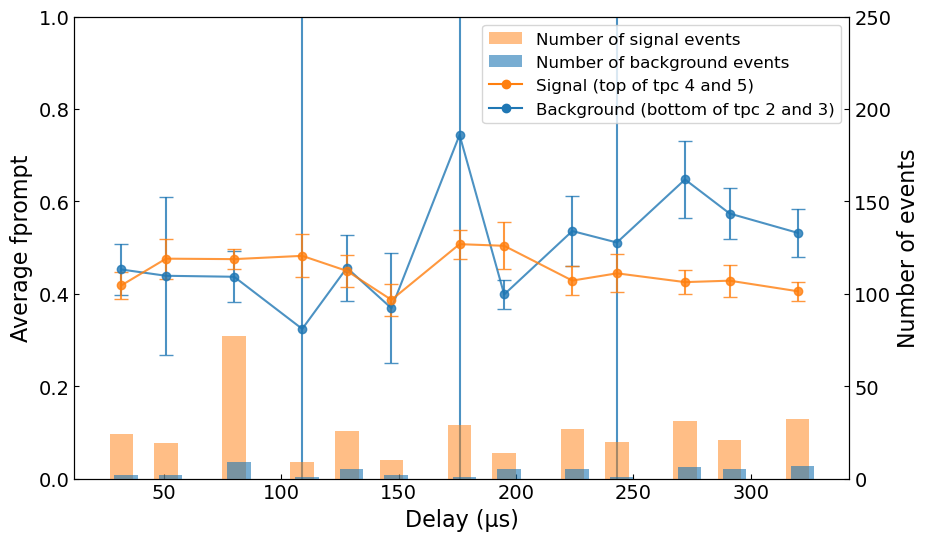

In [3]:
# define background as bottom of tpc 2 and 3
background = df[(df["R"] == "R2") & (df["tpc"].isin([2,3])) & (df["det"].isin([0,1,2,3,8,9,10,11]))]
# define signal as top of tpc 4 and 5
signal = df[(df["R"] == "R2") & (df["tpc"].isin([4,5])) & (df["det"].isin([4,5,6,7,12,13,14,15]))]
# per delay plot the average fprompt
average_fprompt_signal = signal.groupby("delay")["fprompt"].mean()
average_fprompt_background = background.groupby("delay")["fprompt"].mean()
# and the uncertainty on the average fprompt
std_fprompt_signal = signal.groupby("delay")["fprompt"].std()
std_fprompt_signal.fillna(1, inplace=True)
std_fprompt_background = background.groupby("delay")["fprompt"].std()
std_fprompt_background.fillna(1, inplace=True)
# divide std by sqrt(N) to get uncertainty on the mean
num_events_signal = signal.groupby("delay").size()
num_events_background = background.groupby("delay").size()
std_fprompt_signal = std_fprompt_signal / np.sqrt(num_events_signal)
std_fprompt_background = std_fprompt_background / np.sqrt(num_events_background)

plt.figure(figsize=(10, 6))
plt.errorbar(average_fprompt_background.index, average_fprompt_background, std_fprompt_background, capsize=5, marker="o", label="Background (bottom of tpc 2 and 3)", zorder=100, alpha=0.8)
plt.errorbar(average_fprompt_signal.index, average_fprompt_signal, std_fprompt_signal, capsize=5, marker="o", label="Signal (top of tpc 4 and 5)", zorder=100, alpha=0.8)
plt.ylim(0,1)
plt.ylabel("Average fprompt", fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)
plt.xlabel("Delay (μs)", fontsize=16)
ax2 = plt.gca().twinx()
ax2.bar(num_events_signal.index, num_events_signal, width=10, color="tab:orange", label="Number of signal events", alpha=0.5)
ax2.bar(num_events_background.index+2, num_events_background, width=10, color="tab:blue", label="Number of background events", alpha=0.6)
ax2.errorbar(np.nan, np.nan, marker="o", c="tab:orange", label="Signal (top of tpc 4 and 5)")
ax2.errorbar(np.nan, np.nan, marker="o", c="tab:blue", label="Background (bottom of tpc 2 and 3)")
plt.ylabel("Number of events", fontsize=16)
plt.xlabel("Delay (μs)", fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)
plt.ylim(0,250)
plt.legend(fontsize=12)
plt.show()

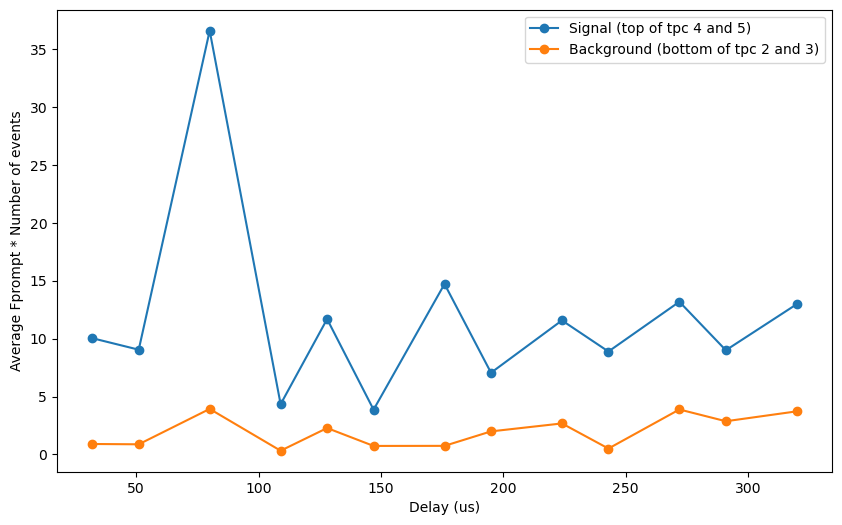

In [4]:
# plot average fprompt times number of events in each bin
plt.figure(figsize=(10, 6))
plt.plot(average_fprompt_signal.index, average_fprompt_signal * num_events_signal, marker="o", label="Signal (top of tpc 4 and 5)")
plt.plot(average_fprompt_background.index, average_fprompt_background * num_events_background, marker="o", label="Background (bottom of tpc 2 and 3)")
plt.ylabel("Average Fprompt * Number of events")
plt.xlabel("Delay (us)")
plt.legend()
plt.show()

## Charge-based selection (Edgar's clustering)

In [5]:
# Load Edgar's charge-cluster CSVs
source_csv = "/global/cfs/cdirs/dune/users/edgarmao/NeutronSim/Analysis/2x2_neutron_sources/AmBe/output/eps1_minsamples4/ambe_bin2_one_trig_32us_window_eps1size4.csv"
bsource_csv = "/global/cfs/cdirs/dune/users/edgarmao/NeutronSim/Analysis/2x2_neutron_sources/AmBe/output/eps1_minsamples4/nosource_ambe_bin2_one_trig_32us_window_eps1size4.csv"
edgar_df = pd.read_csv(source_csv)
b_df = pd.read_csv(bsource_csv)

min_charge_hits = 5

print("=== Source CSV ===")
print(f"  Total charge hits:          {len(edgar_df)}")
print(f"  Files covered (file_id):    {edgar_df['file_id'].nunique()}  ({edgar_df['file_id'].min():.0f}–{edgar_df['file_id'].max():.0f})")
print(f"  Clustered hits (label≠-1):  {(edgar_df['cluster_label'] != -1).sum()}")
clustered_src = edgar_df[edgar_df["cluster_label"] != -1]
valid_src = clustered_src.groupby(["file_id", "light_id"]).filter(lambda x: len(x) > min_charge_hits)
print(f"  Events with >{min_charge_hits} charge hits per light_id: {valid_src.groupby(['file_id','light_id']).ngroups}")

print("\n=== Background CSV ===")
print(f"  Total charge hits:          {len(b_df)}")
print(f"  Files covered (file_id):    {b_df['file_id'].nunique()}  ({b_df['file_id'].min():.0f}–{b_df['file_id'].max():.0f})")
print(f"  Clustered hits (label≠-1):  {(b_df['cluster_label'] != -1).sum()}")
clustered_bkg = b_df[b_df["cluster_label"] != -1]
valid_bkg = clustered_bkg.groupby(["file_id", "light_id"]).filter(lambda x: len(x) > min_charge_hits)
print(f"  Events with >{min_charge_hits} charge hits per light_id: {valid_bkg.groupby(['file_id','light_id']).ngroups}")

=== Source CSV ===
  Total charge hits:          407478
  Files covered (file_id):    62  (0–62)
  Clustered hits (label≠-1):  63385
  Events with >5 charge hits per light_id: 683

=== Background CSV ===
  Total charge hits:          89337
  Files covered (file_id):    20  (0–19)
  Clustered hits (label≠-1):  10616
  Events with >5 charge hits per light_id: 136


In [6]:
file_ids = {}
bfile_ids = {}
for num, file in enumerate(os.listdir("/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin2/one_trig_32us_window")):
    file_ids[num] = file

for num, file in enumerate(os.listdir("/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source")):
    bfile_ids[num] = file

In [7]:
source_path = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin2/one_trig_32us_window/"
bsource_path = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/"

def extract_events(csv_df, file_ids_map, hdf5_path, min_charge_hits=min_charge_hits, max_files=None):
    """
    For each valid (file_id, light_id) in csv_df, open the corresponding HDF5 file
    and extract light quantities. Returns a DataFrame with one row per event.

    Columns: file_id, light_id, n_charge_hits, charge_x/y/z (centroid),
             charge_E/Q (summed), fprompt (sum_hit with max integral),
             integral (max sum_hit), integral_total (all valid sum_hits),
             tpc, det, n_valid_sumhits.
    """
    file_ids_in_csv = sorted(csv_df["file_id"].dropna().unique().astype(int))
    if max_files is not None:
        file_ids_in_csv = file_ids_in_csv[:max_files]

    records = []
    for file_id in file_ids_in_csv:
        if file_id not in file_ids_map:
            print(f"  Warning: file_id {file_id} not in HDF5 directory, skipping")
            continue

        matching = csv_df[(csv_df["cluster_label"] != -1) & (csv_df["file_id"] == file_id)]
        valid_groups = matching.groupby("light_id").filter(lambda x: len(x) > min_charge_hits)
        if len(valid_groups) == 0:
            continue

        data = h5flow.data.H5FlowDataManager(hdf5_path + file_ids_map[file_id], "r")
        try:
            for light_id, group in valid_groups.groupby("light_id"):
                sum_hits = data['/light/events/', 'light/sum_hits'][int(light_id)]
                fprompt  = np.ma.filled(sum_hits["fprompt"],  np.nan)
                integral = np.ma.filled(sum_hits["integral"], np.nan)
                tpc      = np.ma.filled(sum_hits["tpc"].astype(int), -1)
                det      = np.ma.filled(sum_hits["det"].astype(int), -1)

                valid_mask = ~np.isnan(fprompt)

                if valid_mask.sum() > 0:
                    best_idx       = np.nanargmax(integral)
                    fprompt_best   = float(fprompt[best_idx])
                    integral_best  = float(integral[best_idx])
                    tpc_best       = int(tpc[best_idx])
                    det_best       = int(det[best_idx])
                else:
                    fprompt_best  = np.nan
                    integral_best = np.nan
                    tpc_best      = -1
                    det_best      = -1

                records.append({
                    "file_id":         file_id,
                    "light_id":        int(light_id),
                    "n_charge_hits":   len(group),
                    "charge_x":        group["x"].mean(),
                    "charge_y":        group["y"].mean(),
                    "charge_z":        group["z"].mean(),
                    "charge_E":        group["E"].sum(),
                    "charge_Q":        group["Q"].sum(),
                    "fprompt":         fprompt_best,
                    "integral":        integral_best,
                    "integral_total":  float(np.nansum(integral[valid_mask])),
                    "tpc":             tpc_best,
                    "det":             det_best,
                    "n_valid_sumhits": int(valid_mask.sum()),
                })
        finally:
            data.finish()

    return pd.DataFrame(records)


MAX_FILES = None  # increase to process more files

print("Extracting source events...")
events_df = extract_events(edgar_df, file_ids, source_path, max_files=MAX_FILES)
print(f"  → {len(events_df)} events from {events_df['file_id'].nunique()} files")

print("Extracting background events...")
bevents_df = extract_events(b_df, bfile_ids, bsource_path, max_files=MAX_FILES)
print(f"  → {len(bevents_df)} events from {bevents_df['file_id'].nunique()} files")

Extracting source events...
  → 683 events from 62 files
Extracting background events...
  → 136 events from 20 files


In [8]:
# Summary of extracted events
print("=== Source events_df ===")
print(events_df[["n_charge_hits", "charge_x", "charge_y", "charge_z",
                  "charge_E", "fprompt", "integral", "tpc", "n_valid_sumhits"]].describe().round(2))

print("\n=== Background bevents_df ===")
print(bevents_df[["n_charge_hits", "charge_x", "charge_y", "charge_z",
                   "charge_E", "fprompt", "integral", "tpc", "n_valid_sumhits"]].describe().round(2))

print(f"\nSource events with no valid light sum_hit:     {events_df['fprompt'].isna().sum()} / {len(events_df)}")
print(f"Background events with no valid light sum_hit: {bevents_df['fprompt'].isna().sum()} / {len(bevents_df)}")

=== Source events_df ===
       n_charge_hits  charge_x  charge_y  charge_z  charge_E  fprompt  \
count         683.00    683.00    683.00    683.00    683.00   245.00   
mean           75.47    -11.72     16.20     12.65     33.66     0.39   
std           888.22     31.80     35.55     32.73    372.59     0.12   
min             6.00    -64.39    -60.82    -64.09      1.03     0.07   
25%             6.00    -35.64    -11.64    -10.24      2.24     0.31   
50%             7.00    -16.88     24.83     16.97      3.16     0.36   
75%            10.00     10.58     46.72     39.50      4.30     0.43   
max         22571.00     64.33     61.88     64.09   9267.16     0.89   

       integral     tpc  n_valid_sumhits  
count    245.00  683.00           683.00  
mean     911.46    0.83             1.46  
std     4794.04    2.70             5.31  
min       33.34   -1.00             0.00  
25%      106.76   -1.00             0.00  
50%      197.49   -1.00             0.00  
75%      386.99 

## Comparison plots: charge-selected vs light-selected

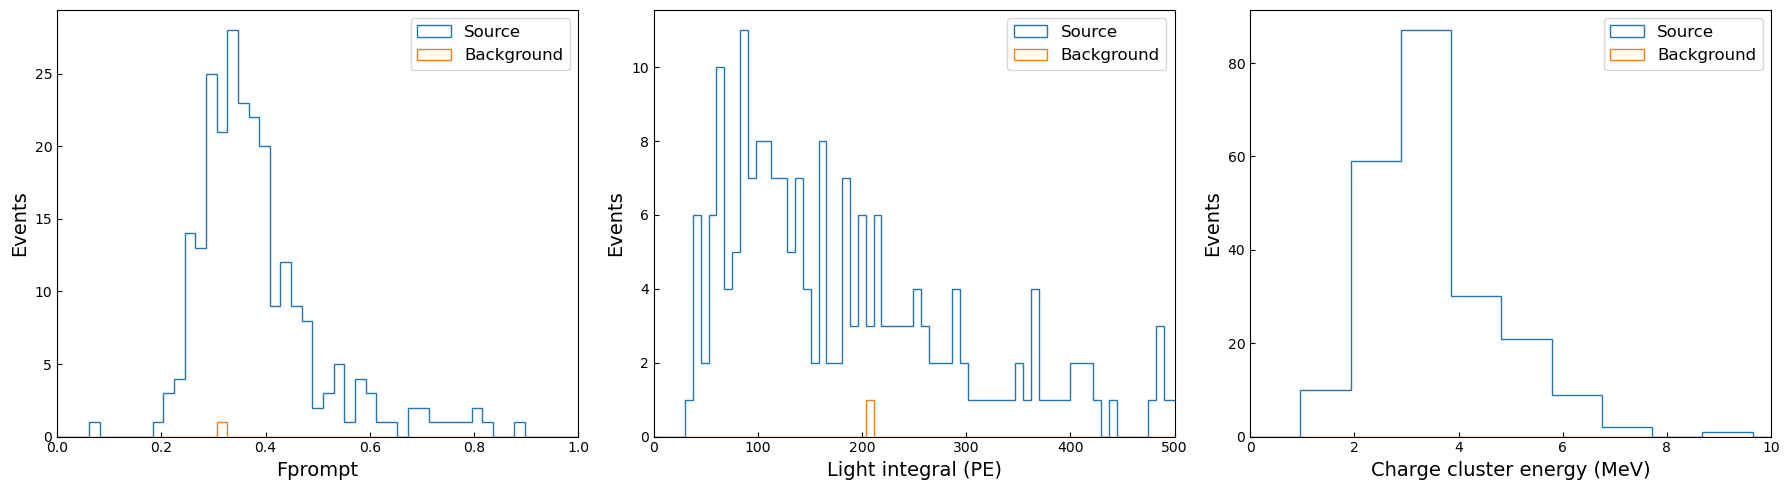

In [9]:
src = events_df.dropna(subset=["fprompt"])
bkg = bevents_df.dropna(subset=["fprompt"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fprompt distribution
bins_fp = np.linspace(0, 1, 50)
axes[0].hist(src["fprompt"],  bins=bins_fp, histtype="step", label="Source")
axes[0].hist(bkg["fprompt"],  bins=bins_fp, histtype="step", label="Background")
axes[0].set_xlabel("Fprompt", fontsize=14)
axes[0].set_ylabel("Events", fontsize=14)
axes[0].set_xlim(0, 1)
axes[0].legend(fontsize=12)
axes[0].tick_params(direction="in")

# Light integral distribution
bins_en = np.linspace(0, 1500, 200)
axes[1].hist(src["integral"],  bins=bins_en, histtype="step", label="Source")
axes[1].hist(bkg["integral"],  bins=bins_en, histtype="step", label="Background")
axes[1].set_xlabel("Light integral (PE)", fontsize=14)
axes[1].set_ylabel("Events", fontsize=14)
axes[1].set_xlim(0,500)
axes[1].legend(fontsize=12)
axes[1].tick_params(direction="in")

# Charge energy distribution
bins_E = np.linspace(0, src["charge_E"].quantile(0.98), 200)
axes[2].hist(src["charge_E"],  bins=bins_E, histtype="step", label="Source")
axes[2].hist(bkg["charge_E"],  bins=bins_E, histtype="step", label="Background")
axes[2].set_xlabel("Charge cluster energy (MeV)", fontsize=14)
axes[2].set_ylabel("Events", fontsize=14)
axes[2].set_xlim(0,10)
axes[2].legend(fontsize=12)
axes[2].tick_params(direction="in")

plt.tight_layout()
plt.show()

## Spatial correlation: charge position vs light trap position

Events used: 380
Median |Δy|: 4.1 mm,  RMS Δy: 18.3 mm
Median |Δz|: 11.1 mm,  RMS Δz: 22.3 mm


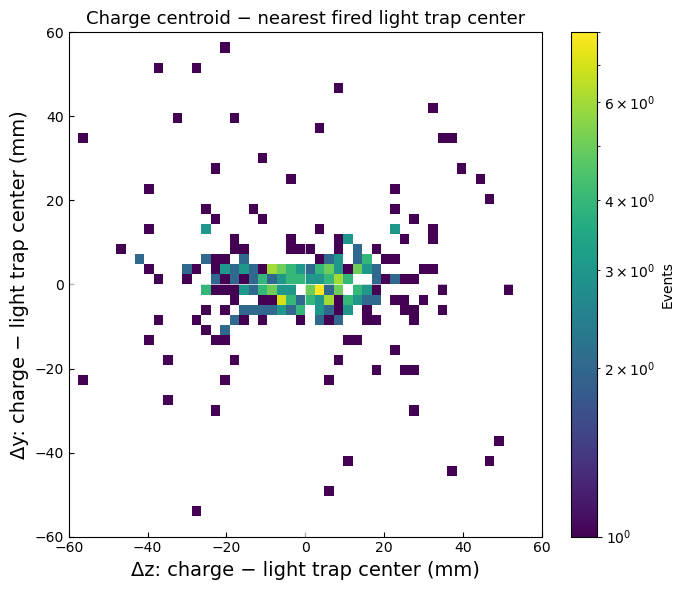

In [10]:
# Quantitative: residual between charge centroid and nearest fired light trap center
# Uses events_df (already extracted) + opens HDF5 files only for boundary coordinates
residuals_y, residuals_z = [], []

file_ids_to_use = sorted(events_df["file_id"].unique())
for file_id in file_ids_to_use:
    file_events = events_df[events_df["file_id"] == file_id]
    data = h5flow.data.H5FlowDataManager(source_path + file_ids[file_id], "r")
    try:
        for _, row in file_events.iterrows():
            sum_hits = data['/light/events/', 'light/sum_hits'][int(row["light_id"])]
            boundary = np.ma.filled(sum_hits["boundary"].astype(float), np.nan)
            fprompt  = np.ma.filled(sum_hits["fprompt"], np.nan)
            valid    = ~np.isnan(fprompt)

            if valid.sum() == 0:
                continue

            centers = (boundary[valid, 0, 1:3] + boundary[valid, 1, 1:3]) / 2  # (n_valid, [y, z])
            charge_yz = np.array([row["charge_y"], row["charge_z"]])
            nearest = centers[np.argmin(np.linalg.norm(centers - charge_yz, axis=1))]

            residuals_y.append(charge_yz[0] - nearest[0])
            residuals_z.append(charge_yz[1] - nearest[1])
    finally:
        data.finish()

residuals_y = np.array(residuals_y)
residuals_z = np.array(residuals_z)
print(f"Events used: {len(residuals_y)}")
print(f"Median |Δy|: {np.median(np.abs(residuals_y)):.1f} mm,  RMS Δy: {residuals_y.std():.1f} mm")
print(f"Median |Δz|: {np.median(np.abs(residuals_z)):.1f} mm,  RMS Δz: {residuals_z.std():.1f} mm")

plt.figure(figsize=(7, 6))
plt.hist2d(residuals_z, residuals_y, bins=50, range=[[-60, 60], [-60, 60]],
           cmap="viridis", norm=LogNorm())
plt.axhline(0, color="white", lw=0.5)
plt.axvline(0, color="white", lw=0.5)
plt.colorbar(label="Events")
plt.xlabel("Δz: charge − light trap center (mm)", fontsize=14)
plt.ylabel("Δy: charge − light trap center (mm)", fontsize=14)
plt.title("Charge centroid − nearest fired light trap center", fontsize=13)
plt.tick_params(direction="in")
plt.tight_layout()
plt.show()

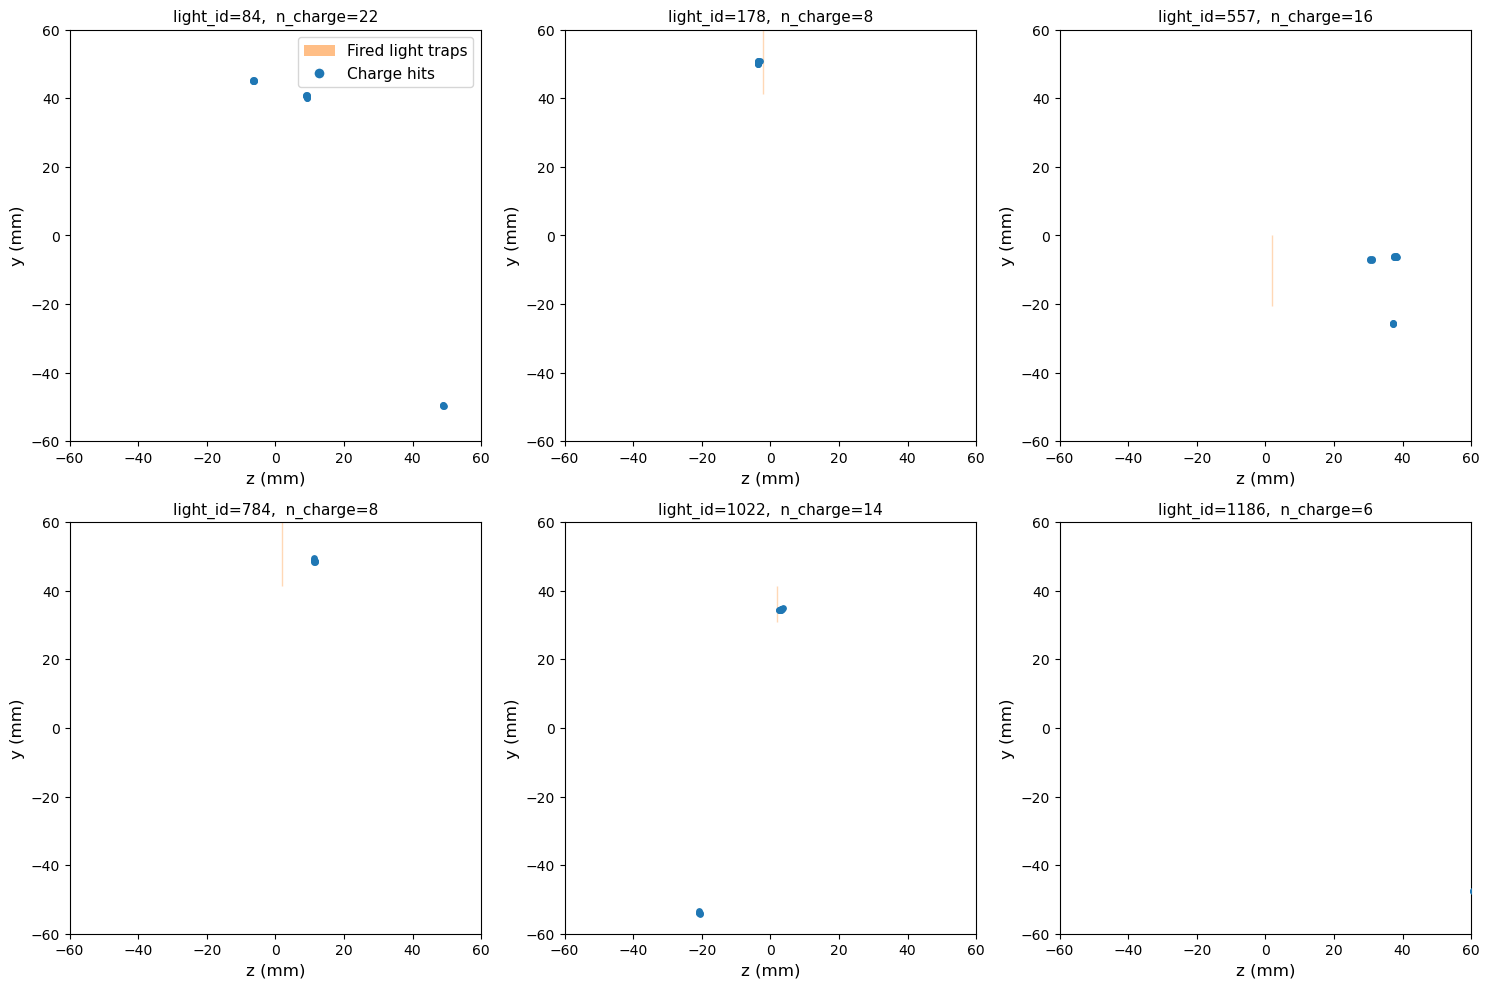

In [11]:
# Visual check: for 6 sample events from file 0, overlay charge hits with fired light trap boundaries
data = h5flow.data.H5FlowDataManager(source_path + file_ids[0], "r")

sample_ids = edgar_df[(edgar_df["cluster_label"] != -1) & (edgar_df["file_id"] == 0)] \
                .groupby("light_id").filter(lambda x: len(x) > 5)["light_id"].unique()[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, event_id in zip(axes, sample_ids):
    charge_hits = edgar_df[(edgar_df["light_id"] == event_id) & (edgar_df["cluster_label"] != -1)]

    sum_hits = data['/light/events/', 'light/sum_hits'][int(event_id)]
    boundary = np.ma.filled(sum_hits["boundary"].astype(float), np.nan)  # (n, 2, 3)
    fprompt  = np.ma.filled(sum_hits["fprompt"], np.nan)
    valid    = ~np.isnan(fprompt)

    for b in boundary[valid]:
        zmin, ymin = b[0, 2], b[0, 1]
        zmax, ymax = b[1, 2], b[1, 1]
        rect = plt.Rectangle((zmin, ymin), zmax - zmin, ymax - ymin,
                              linewidth=1, edgecolor="tab:orange", facecolor="tab:orange", alpha=0.3)
        ax.add_patch(rect)

    ax.scatter(charge_hits["z"], charge_hits["y"], s=15, c="tab:blue", zorder=5)
    ax.set_xlabel("z (mm)", fontsize=12)
    ax.set_ylabel("y (mm)", fontsize=12)
    ax.set_title(f"light_id={int(event_id)},  n_charge={len(charge_hits)}", fontsize=11)
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_aspect("equal")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
axes[0].legend(handles=[
    Patch(facecolor="tab:orange", alpha=0.5, label="Fired light traps"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", markersize=8, label="Charge hits"),
], fontsize=11)

plt.tight_layout()
plt.show()
data.finish()

In [12]:
TRAP_NAME_MAP = [
    # ----- ADC 0 (ACLs module 0) -----
    dict(adc=0, channels=[4,5,6,7,8,9],   name="ACL 2.01", tpc=0, z_side="-z", position="bottom"),
    dict(adc=0, channels=[10,11,12,13,14,15], name="ACL 2.02", tpc=0, z_side="-z", position="top"),
    dict(adc=0, channels=[20,21,22,23,24,25], name="ACL 2.03", tpc=0, z_side="+z", position="bottom"),
    dict(adc=0, channels=[26,27,28,29,30,31], name="ACL 2.04", tpc=0, z_side="+z", position="top"),
    dict(adc=0, channels=[52,53,54,55,56,57], name="ACL 2.05", tpc=1, z_side="-z", position="bottom"),
    dict(adc=0, channels=[58,59,60,61,62,63], name="ACL 2.06", tpc=1, z_side="-z", position="top"),
    dict(adc=0, channels=[36,37,38,39,40,41], name="ACL 2.07", tpc=1, z_side="+z", position="bottom"),
    dict(adc=0, channels=[42,43,44,45,46,47], name="ACL 2.08", tpc=1, z_side="+z", position="top"),

    # ----- ADC 1 (LCMs module 0) -----
    dict(adc=1, channels=[4,5,6,7,8,9],   name="LCM 100,101,102", tpc=0, z_side="-z", position="bottom"),
    dict(adc=1, channels=[10,11,12,13,14,15], name="LCM 103,104,105", tpc=0, z_side="-z", position="top"),
    dict(adc=1, channels=[20,21,22,23,24,25], name="LCM 106,107,108", tpc=0, z_side="+z", position="bottom"),
    dict(adc=1, channels=[26,27,28,29,30,31], name="LCM 109,110,111", tpc=0, z_side="+z", position="top"),
    dict(adc=1, channels=[52,53,54,55,56,57], name="LCM 112,113,114", tpc=1, z_side="-z", position="bottom"),
    dict(adc=1, channels=[58,59,60,61,62,63], name="LCM 115,116,117", tpc=1, z_side="-z", position="top"),
    dict(adc=1, channels=[36,37,38,39,40,41], name="LCM 118,119,120", tpc=1, z_side="+z", position="bottom"),
    dict(adc=1, channels=[42,43,44,45,46,47], name="LCM 121,122,123", tpc=1, z_side="+z", position="top"),

    # ----- ADC 2 (ACLs module 1) -----
    dict(adc=2, channels=[4,5,6,7,8,9],   name="ACL 2.09", tpc=2, z_side="-z", position="bottom"),
    dict(adc=2, channels=[10,11,12,13,14,15], name="ACL 2.10", tpc=2, z_side="-z", position="top"),
    dict(adc=2, channels=[20,21,22,23,24,25], name="ACL 2.11", tpc=2, z_side="+z", position="bottom"),
    dict(adc=2, channels=[26,27,28,29,30,31], name="ACL 2.12", tpc=2, z_side="+z", position="top"),
    dict(adc=2, channels=[52,53,54,55,56,57], name="ACL 2.13", tpc=3, z_side="-z", position="bottom"),
    dict(adc=2, channels=[58,59,60,61,62,63], name="ACL 2.14", tpc=3, z_side="-z", position="top"),
    dict(adc=2, channels=[36,37,38,39,40,41], name="ACL 2.15", tpc=3, z_side="+z", position="bottom"),
    dict(adc=2, channels=[42,43,44,45,46,47], name="ACL 2.16", tpc=3, z_side="+z", position="top"),

    # ----- ADC 3 (LCMs module 1) -----
    dict(adc=3, channels=[20,21,22,23,24,25], name="LCM 124,125,126", tpc=2, z_side="-z", position="bottom"),
    dict(adc=3, channels=[26,27,28,29,30,31], name="LCM 127,128,129", tpc=2, z_side="-z", position="top"),
    dict(adc=3, channels=[4,5,6,7,8,9],   name="LCM 130,131,132", tpc=2, z_side="+z", position="bottom"),
    dict(adc=3, channels=[10,11,12,13,14,15], name="LCM 133,134,135", tpc=2, z_side="+z", position="top"),
    dict(adc=3, channels=[52,53,54,55,56,57], name="LCM 136,137,138", tpc=3, z_side="-z", position="bottom"),
    dict(adc=3, channels=[58,59,60,61,62,63], name="LCM 139,140,141", tpc=3, z_side="-z", position="top"),
    dict(adc=3, channels=[36,37,38,39,40,41], name="LCM 142,143,144", tpc=3, z_side="+z", position="bottom"),
    dict(adc=3, channels=[42,43,44,45,46,47], name="LCM 145,146,147", tpc=3, z_side="+z", position="top"),

    # ----- ADC 4 (mix module 2) -----
    dict(adc=4, channels=[42,43,44,45,46,47], name="ACL 2.17",       tpc=4, z_side="-z", position="bottom"),
    dict(adc=4, channels=[36,37,38,39,40,41], name="ACL 2.18",       tpc=4, z_side="-z", position="top"),
    dict(adc=4, channels=[52,53,54,55,56,57], name="LCM 148,149,150",tpc=4, z_side="+z", position="bottom"),
    dict(adc=4, channels=[58,59,60,61,62,63], name="LCM 151,152,153",tpc=4, z_side="+z", position="top"),
    dict(adc=4, channels=[26,27,28,29,30,31], name="ACL 2.19",       tpc=5, z_side="-z", position="bottom"),
    dict(adc=4, channels=[20,21,22,23,24,25], name="ACL 2.20",       tpc=5, z_side="-z", position="top"),
    dict(adc=4, channels=[10,11,12,13,14,15], name="ACL 2.21",       tpc=5, z_side="+z", position="bottom"),
    dict(adc=4, channels=[4,5,6,7,8,9],   name="ACL 2.22",           tpc=5, z_side="+z", position="top"),

    # ----- ADC 5 (mix module 2) -----
    dict(adc=5, channels=[42,43,44,45,46,47], name="LCM 154,155,156",tpc=4, z_side="-z", position="bottom"),
    dict(adc=5, channels=[58,59,60,61,62,63], name="ACL 2.23",       tpc=4, z_side="+z", position="bottom"),
    dict(adc=5, channels=[52,53,54,55,56,57], name="ACL 2.24",       tpc=4, z_side="+z", position="top"),
    dict(adc=5, channels=[36,37,38,39,40,41], name="LCM 157,158,159",tpc=4, z_side="+z", position="top"),
    dict(adc=5, channels=[26,27,28,29,30,31], name="LCM 160,161,162",tpc=5, z_side="-z", position="bottom"),
    dict(adc=5, channels=[20,21,22,23,24,25], name="LCM 163,164,165",tpc=5, z_side="-z", position="top"),
    dict(adc=5, channels=[10,11,12,13,14,15], name="LCM 166,167,168",tpc=5, z_side="+z", position="bottom"),
    dict(adc=5, channels=[4,5,6,7,8,9],   name="LCM 169,170,171",    tpc=5, z_side="+z", position="top"),

    # ----- ADC 6 (ACLs module 3) -----
    dict(adc=6, channels=[4,5,6,7,8,9],   name="ACL 2.25", tpc=6, z_side="-z", position="bottom"),
    dict(adc=6, channels=[10,11,12,13,14,15], name="ACL 2.26", tpc=6, z_side="-z", position="top"),
    dict(adc=6, channels=[20,21,22,23,24,25], name="ACL 2.27", tpc=6, z_side="+z", position="bottom"),
    dict(adc=6, channels=[26,27,28,29,30,31], name="ACL 2.28", tpc=6, z_side="+z", position="top"),
    dict(adc=6, channels=[52,53,54,55,56,57], name="ACL 2.29", tpc=7, z_side="-z", position="bottom"),
    dict(adc=6, channels=[58,59,60,61,62,63], name="ACL 2.30", tpc=7, z_side="-z", position="top"),
    dict(adc=6, channels=[36,37,38,39,40,41], name="ACL 2.31", tpc=7, z_side="+z", position="bottom"),
    dict(adc=6, channels=[42,43,44,45,46,47], name="ACL 2.32", tpc=7, z_side="+z", position="top"),

    # ----- ADC 7 (LCMs module 3) -----
    dict(adc=7, channels=[4,5,6,7,8,9],   name="LCM 172,173,174", tpc=6, z_side="-z", position="bottom"),
    dict(adc=7, channels=[10,11,12,13,14,15], name="LCM 175,176,177", tpc=6, z_side="-z", position="top"),
    dict(adc=7, channels=[20,21,22,23,24,25], name="LCM 178,179,180", tpc=6, z_side="+z", position="bottom"),
    dict(adc=7, channels=[26,27,28,29,30,31], name="LCM 181,182,183", tpc=6, z_side="+z", position="top"),
    dict(adc=7, channels=[52,53,54,55,56,57], name="LCM 184,185,186", tpc=7, z_side="-z", position="bottom"),
    dict(adc=7, channels=[58,59,60,61,62,63], name="LCM 187,188,189", tpc=7, z_side="-z", position="top"),
    dict(adc=7, channels=[36,37,38,39,40,41], name="LCM 190,191,192", tpc=7, z_side="+z", position="bottom"),
    dict(adc=7, channels=[42,43,44,45,46,47], name="LCM 193,194,195", tpc=7, z_side="+z", position="top"),
]


In [13]:
# Build a lookup DataFrame from TRAP_NAME_MAP.
# det = local index within each TPC (order of appearance in the map).
# This is the assumed mapping between sum_hits["det"] and the trap list.
tpc_counts = {}
rows = []
for entry in TRAP_NAME_MAP:
    tpc = entry["tpc"]
    det = tpc_counts.get(tpc, 0)
    tpc_counts[tpc] = det + 1
    rows.append({
        "tpc":       tpc,
        "det":       det,
        "trap_name": entry["name"],
        "trap_type": "ACL" if entry["name"].startswith("ACL") else "LCM",
        "position":  entry["position"],
        "z_side":    entry["z_side"],
        "adc":       entry["adc"],
    })
trap_lookup = pd.DataFrame(rows)
print("Traps per TPC:")
print(trap_lookup.groupby("tpc").size().to_string())
print()

# Merge trap metadata into events_df / bevents_df on (tpc, det)
cols = ["tpc", "det", "trap_name", "trap_type", "position", "z_side"]
events_df  = events_df.merge(trap_lookup[cols],  on=["tpc", "det"], how="left")
bevents_df = bevents_df.merge(trap_lookup[cols], on=["tpc", "det"], how="left")

print("Source events by trap_type:")
print(events_df["trap_type"].value_counts().to_string())
print()
print("Source events by position:")
print(events_df["position"].value_counts().to_string())


Traps per TPC:
tpc
0    8
1    8
2    8
3    8
4    8
5    8
6    8
7    8

Source events by trap_type:
trap_type
LCM    122
ACL     66

Source events by position:
position
top       109
bottom     79


After cuts — source: 295 events, background: 5 events


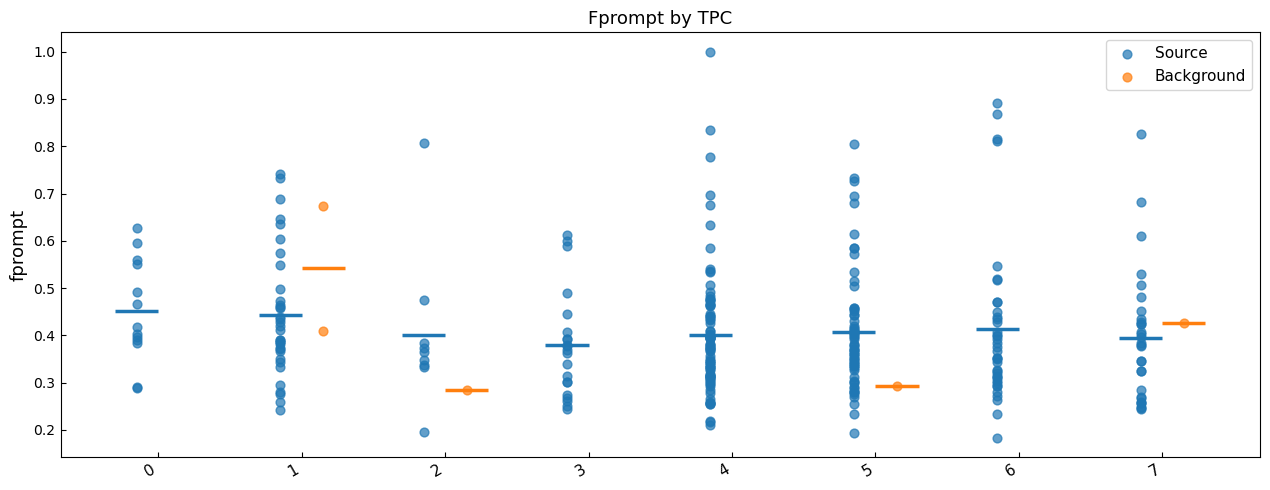

After cuts — source: 295 events, background: 5 events


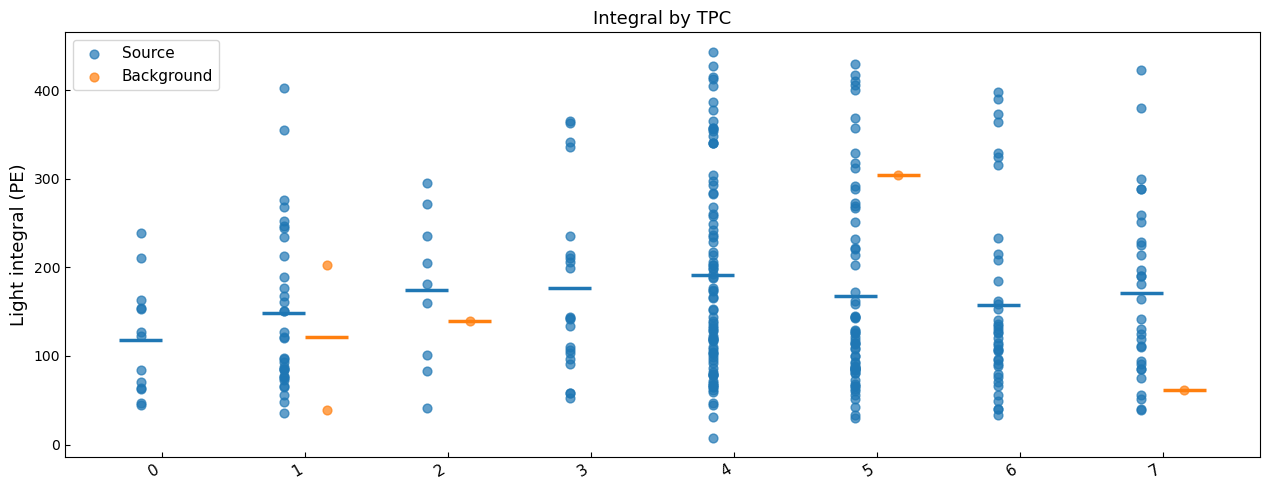

After cuts — source: 295 events, background: 5 events


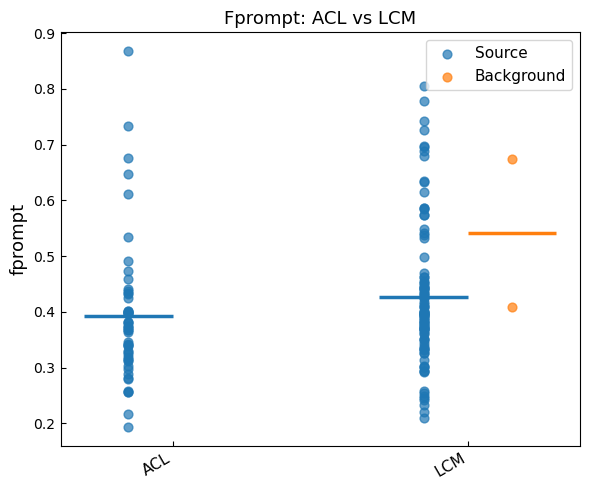

After cuts — source: 295 events, background: 5 events


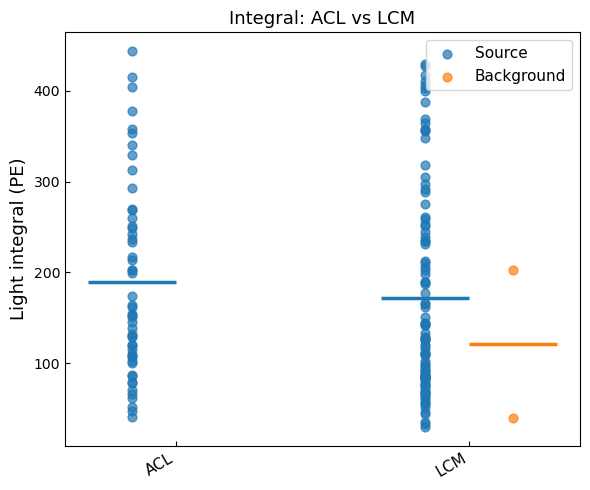

After cuts — source: 295 events, background: 5 events


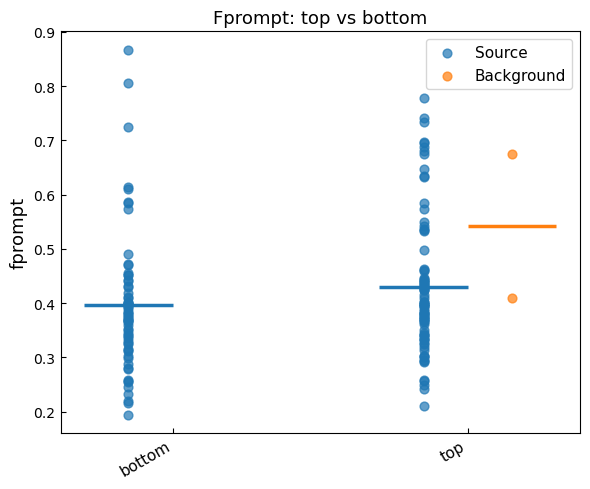

After cuts — source: 55 events, background: 0 events


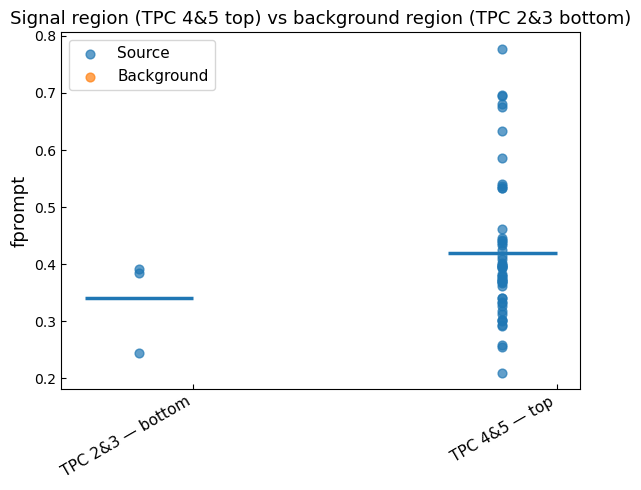

After cuts — source: 55 events, background: 0 events


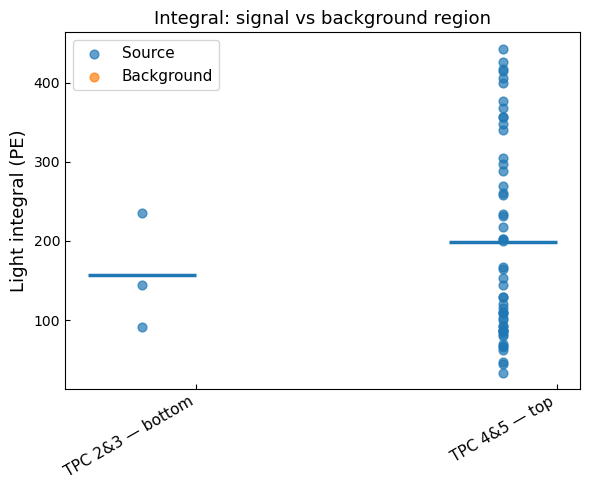

In [16]:
def apply_cuts(df, cuts):
    """Apply range cuts to a DataFrame.
    cuts = {"col": (min, max)}  — use None for no bound on either side.
    """
    if not cuts:
        return df
    mask = pd.Series(True, index=df.index)
    for col, (lo, hi) in cuts.items():
        if lo is not None:
            mask &= df[col] >= lo
        if hi is not None:
            mask &= df[col] <= hi
    return df[mask]


def compare_groups(src, bkg, group_col, quantity="fprompt", ylabel=None, title="", cuts=None):
    """
    Strip plot comparing source vs background for each category in group_col.
    Individual points are shown; horizontal lines mark the group mean.

    cuts : dict, optional
        Range filters applied before grouping, e.g.
        {"charge_E": (1, 10), "integral": (None, 500)}
        Use None for an unbounded side.
    """
    if cuts:
        src = apply_cuts(src, cuts)
        bkg = apply_cuts(bkg, cuts)
        print(f"After cuts — source: {len(src)} events, background: {len(bkg)} events")

    groups = sorted(set(src[group_col].dropna().unique()) | set(bkg[group_col].dropna().unique()))
    fig, ax = plt.subplots(figsize=(max(6, len(groups) * 1.6), 5))

    for i, grp in enumerate(groups):
        s = src[src[group_col] == grp][quantity].dropna()
        b = bkg[bkg[group_col] == grp][quantity].dropna()
        ax.scatter([i - 0.15] * len(s), s, color="tab:blue",   alpha=0.7, s=40, zorder=5,
                   label="Source"     if i == 0 else "")
        ax.scatter([i + 0.15] * len(b), b, color="tab:orange", alpha=0.7, s=40, zorder=5,
                   label="Background" if i == 0 else "")
        if len(s): ax.hlines(s.mean(), i - 0.3, i,       colors="tab:blue",   lw=2.5)
        if len(b): ax.hlines(b.mean(), i,       i + 0.3, colors="tab:orange", lw=2.5)

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([str(g) for g in groups], rotation=30, ha="right", fontsize=11)
    ax.set_ylabel(ylabel or quantity, fontsize=13)
    ax.set_title(title, fontsize=13)
    ax.tick_params(direction="in")
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


src = events_df.dropna(subset=["fprompt"])
bkg = bevents_df.dropna(subset=["fprompt"])

# Optional cuts — edit these to filter events before grouping
cuts = {
    "charge_E": (1, 5),    # MeV  — set to None to remove a bound, e.g. (None, 10)
    "integral": (None, 450), # PE   — only upper bound here
}

# ── By TPC ────────────────────────────────────────────────────────────────────
compare_groups(src, bkg, "tpc", quantity="fprompt",  title="Fprompt by TPC", cuts=cuts)
compare_groups(src, bkg, "tpc", quantity="integral",  ylabel="Light integral (PE)", title="Integral by TPC", cuts=cuts)

# ── ACL vs LCM ────────────────────────────────────────────────────────────────
compare_groups(src, bkg, "trap_type", quantity="fprompt",  title="Fprompt: ACL vs LCM", cuts=cuts)
compare_groups(src, bkg, "trap_type", quantity="integral",  ylabel="Light integral (PE)", title="Integral: ACL vs LCM", cuts=cuts)

# ── Top vs bottom ─────────────────────────────────────────────────────────────
compare_groups(src, bkg, "position", quantity="fprompt",  title="Fprompt: top vs bottom", cuts=cuts)

# ── Specific region: bottom of TPC 2&3 vs top of TPC 4&5 ─────────────────────
def label_region(df):
    df = df.copy()
    df["region"] = None
    df.loc[(df["tpc"].isin([2,3])) & (df["position"] == "bottom"), "region"] = "TPC 2&3 — bottom"
    df.loc[(df["tpc"].isin([4,5])) & (df["position"] == "top"),    "region"] = "TPC 4&5 — top"
    return df.dropna(subset=["region"])

compare_groups(label_region(src), label_region(bkg),
               "region", quantity="fprompt",
               title="Signal region (TPC 4&5 top) vs background region (TPC 2&3 bottom)", cuts=cuts)
compare_groups(label_region(src), label_region(bkg),
               "region", quantity="integral", ylabel="Light integral (PE)",
               title="Integral: signal vs background region", cuts=cuts)
